# ORC1 Fiber Assay Analysis

**Purpose:** Compare replication speed between WT and MGS variants.

**Author:** Elena Lopatukhina
**Date:** 2026-07-14

## Workflow
1. Load data
2. Clean data
3. Calculate fiber speed
4. Statistical analysis
5. Plot figures
6. Save results

# 1. Libraries import

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, ttest_ind

# 2. Data loading

In [2]:
input_dir = "/mnt/c/users/helen/Desktop/FIBERS"

In [3]:
dfs = []

for root, dirs, files in os.walk(input_dir):
    for filename in files:
        if filename.lower().endswith(".csv"):

            path = os.path.join(root, filename)

            df = pd.read_csv(path)
            
            # If everything ended up in one column, try semicolon
            if df.shape[1] == 1:
                df = pd.read_csv(path, sep=";")

            # Optional metadata
            df["File"] = os.path.splitext(filename)[0].replace(" ", "_")
            df["Path"] = path

            dfs.append(df) 

# Combine all tables
data = pd.concat(dfs, ignore_index=True)

# Create ROI column
data['ROI'] = data['Label'].apply(lambda x: x.split(":")[1])

# Create Sample name column empty (custom parsing of filenames)
data['Sample_name'] = None

# Delete first 3 columns
data.drop(data.columns[[0, 1, 2]], axis=1, inplace=True)

# Reorder columns
data = data[
    [
        "Sample_name",
        "File",
        "Measurement_type",
        "Length",
        "ROI",
        "Path"
    ]
]

In [6]:
# Create Sample name column empty (custom parsing of filenames)
data['Sample_name'] = data['File'].apply(lambda x: x.split("_")[1].split("-")[0])

data["Sample_name"] = data["Sample_name"].apply(
    lambda x: "WT" if "1h15min" in x else x
)

mask = (
    (data["Sample_name"] == "HaloEmpty") &
    (data["File"].str.contains("siORC1_HaloEmpty", na=False))
)
data.loc[mask, "Sample_name"] = "siORC1"

# Update only rows where Sample_name == "HaloEmpty" and File contains "siSCR_HaloEmpty"
mask = (
    (data["Sample_name"] == "HaloEmpty") &
    (data["File"].str.contains("siSCR_HaloEmpty", na=False))
)

data.loc[mask, "Sample_name"] = "siSCR"

# Info about samples
sample_names = set(data["Sample_name"])
print(f"The amount of samples is: {len(sample_names)}.")
print(f"There are: {sample_names}")

The amount of samples is: 8.
There are: {'MGS3', 'siORC1', 'MGS4', 'siSCR', 'WT', 'MGS5', 'MGS1', 'MGS2'}


In [7]:
# Split data into 2 dataframes
speed = data[data['Measurement_type']=='Fiber_length']
iod = data[data['Measurement_type']=='Interorigin_distance']

## Check data

In [16]:
speed.head()

,Sample_name,File,Measurement_type,Length,ROI,Path
0,MGS1,siORC1_MGS1-02_Fiber_length,Fiber_length,51.108,0303-0404,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
1,MGS1,siORC1_MGS1-02_Fiber_length,Fiber_length,37.202,0273-0360,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
2,MGS1,siORC1_MGS1-03_Fiber_length,Fiber_length,55.027,0944-0253,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
3,MGS1,siORC1_MGS1-03_Fiber_length,Fiber_length,68.244,0968-0321,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
4,MGS1,siORC1_MGS1-03_Fiber_length,Fiber_length,100.000,0581-0161,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...


In [17]:
iod.head()

,Sample_name,File,Measurement_type,Length,ROI,Path
18,MGS1,siORC1_MGS1-04_Interorigin_distance,Interorigin_distance,125.399,0550-0404,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
19,MGS1,siORC1_MGS1-04_Interorigin_distance,Interorigin_distance,171.724,0477-0521,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
20,MGS1,siORC1_MGS1-04_Interorigin_distance,Interorigin_distance,97.546,0646-0786,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
27,MGS1,siORC1_MGS1-07_Interorigin_distance,Interorigin_distance,106.301,0493-0678,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
28,MGS1,siORC1_MGS1-07_Interorigin_distance,Interorigin_distance,232.019,0814-0659,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...


# 3. Process replication speed data

In [18]:
conversion_factor = 2.59 # kb/µm
time = 20 # minutes

# Checking speed file
counts = speed.groupby("File").size()
odd_files = counts[counts % 2 != 0].index.tolist()

if len(odd_files) == 0:
    print("All files contain an even number of fibers.")
else:
    print("The following files contain an odd number of fibers will be removed:")
    print(*odd_files, sep="\n")
    
    # Removing odd files from speed dataframe
    speed = speed[~speed["File"].isin(odd_files)].copy()

The following files contain an odd number of fibers will be removed:
siORC1_MGS2-03_Fiber_length
siORC1_MGS4_Fiber_length


In [ ]:
# Add extra inedex to group pairs of files
speed["Index"] = speed.groupby("File").cumcount() // 2

# Calculate sum of fiber length in pairs
speed_processed = speed.groupby(["File", "Index"], as_index=False).agg(
        Total_Length=("Length", "sum"),
        ROI=("ROI", list),
        Path=("Path", "first"),
        Sample_name=("Sample_name", "first")
        )

# Convert speed to kb/min
speed_processed['Speed_kb_min'] = speed_processed['Total_Length'].apply(lambda x: x * conversion_factor / time)

# Delete extra columns
replication_speed = speed_processed[['Sample_name', 'File', 'Speed_kb_min', 'ROI', 'Path']]

There are the following samples: {'MGS3', 'siORC1', 'MGS4', 'siSCR', 'WT', 'MGS5', 'MGS1', 'MGS2'}


In [20]:
replication_speed.head()

,Sample_name,File,Speed_kb_min,ROI,Path
0,WT,HCl_1h15min_15o-02_Fiber_length,7.268058,"[0172-0998, 0159-1032]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
1,WT,HCl_1h15min_15o-06_Fiber_length,12.962302,"[0660-0135, 0624-0181]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
2,WT,HCl_1h15min_15o-06_Fiber_length,9.868806,"[0627-0140, 0600-0174]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
3,WT,HCl_1h15min_15o-06_Fiber_length,12.087918,"[0513-0309, 0472-0351]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...
4,WT,HCl_1h15min_15o-07_Fiber_length,8.567072,"[0490-0561, 0450-0575]",/mnt/c/users/helen/Desktop/FIBERS/WT_fibers_sp...


# 4. Process IOD data

In [21]:
iod['IOD_kb'] = iod['Length'].apply(lambda x: x * conversion_factor)
iod_kb = iod[["Sample_name", "File", 'IOD_kb', 'ROI', 'Path']]

iod_kb.head()

,Sample_name,File,IOD_kb,ROI,Path
18,MGS1,siORC1_MGS1-04_Interorigin_distance,324.78341,0550-0404,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
19,MGS1,siORC1_MGS1-04_Interorigin_distance,444.76516,0477-0521,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
20,MGS1,siORC1_MGS1-04_Interorigin_distance,252.64414,0646-0786,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
27,MGS1,siORC1_MGS1-07_Interorigin_distance,275.31959,0493-0678,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
28,MGS1,siORC1_MGS1-07_Interorigin_distance,600.92921,0814-0659,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...


# 5. Basic statistics

## 5.1 Replication speed

In [22]:
stats_speed = (
    replication_speed.groupby("Sample_name")["Speed_kb_min"]
    .agg(
        Count="count",
        Mean="mean",
        SD="std",
    )
)

stats_speed

,Count,Mean,SD
Sample_name,,,
MGS1,31,14.462197,5.094174
MGS2,57,13.099020,3.533363
MGS3,64,13.924694,3.671007
MGS4,44,14.552433,4.588174
MGS5,23,14.225507,3.890711
WT,52,13.159200,4.487109
siORC1,42,13.182379,3.049485
siSCR,23,11.191013,3.565813


## 5.2 IOD

In [23]:
stats_iod = (
    iod_kb.groupby("Sample_name")["IOD_kb"]
    .agg(
        Count="count",
        Mean="mean",
        SD="std",
    )
)

stats_iod

,Count,Mean,SD
Sample_name,,,
MGS1,21,417.369250,116.380943
MGS2,48,379.444605,118.638065
MGS3,48,443.572735,145.396456
MGS4,23,435.897000,139.869267
MGS5,25,437.377548,139.497763
WT,50,342.657570,137.682836
siORC1,22,487.598109,184.845614
siSCR,55,323.844935,107.834065


# 6. Processing outliers in data

## 6.1 Replication speed

## 6.2 IOD

# Graphs

## Replication speed graph

Plot is saved in the directory: /mnt/c/users/helen/Desktop/FIBERS


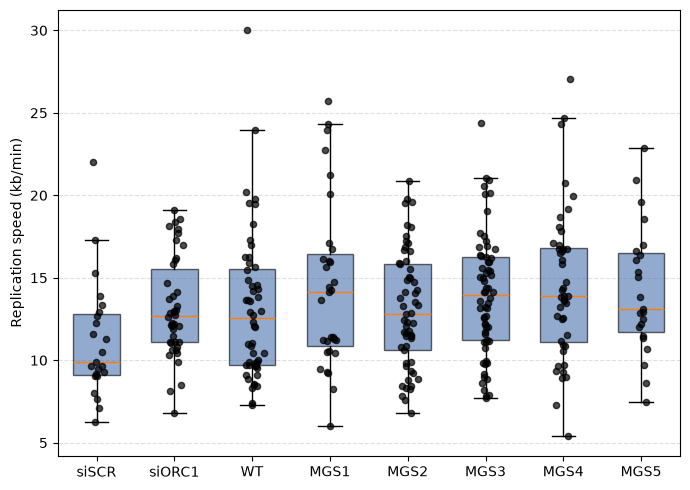

In [24]:
plt.figure(figsize=(7, 5))

# Variables
data_plot = replication_speed
var = "Speed_kb_min"

# Order of groups (optional)
sample_order = ["siSCR", "siORC1", "WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

groups = []
labels = []

for sample in sample_order:
        values = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ]
        
        groups.append(values)
        labels.append(sample)

    

bp = plt.boxplot(
    groups,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
)

for box in bp["boxes"]:
    box.set(facecolor="#4C72B0", alpha=0.6)

# Jittered dots
for i, values in enumerate(groups, start=1):
    x = np.random.normal(i, 0.05, len(values))
    plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

plt.ylabel("Replication speed (kb/min)")
plt.xticks(range(1, len(labels) + 1), labels)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{input_dir}/replication_speed_boxplot.png", dpi=600, bbox_inches="tight")
print(f"Plot is saved in the directory: {input_dir}")

plt.show()

## IOD graph

Plot is saved in the directory: /mnt/c/users/helen/Desktop/FIBERS


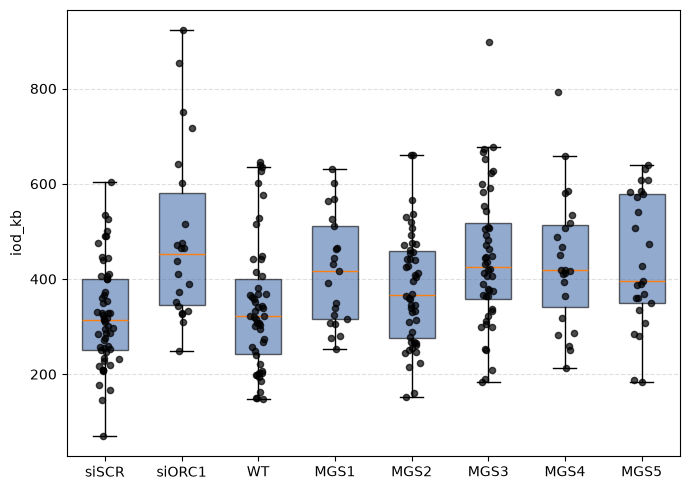

In [25]:
plt.figure(figsize=(7, 5))

# Variables
data_plot = iod_kb
var = "IOD_kb"

# Order of groups (optional)
sample_order = ["siSCR", "siORC1", "WT", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]

groups = []
labels = []

for sample in sample_order:
        values = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ]
        
        groups.append(values)
        labels.append(sample)

    

bp = plt.boxplot(
    groups,
    patch_artist=True,
    showfliers=False,
    widths=0.6,
)

for box in bp["boxes"]:
    box.set(facecolor="#4C72B0", alpha=0.6)

# Jittered dots
for i, values in enumerate(groups, start=1):
    x = np.random.normal(i, 0.05, len(values))
    plt.scatter(x, values, s=20, color="black", alpha=0.7, zorder=3)

plt.ylabel("iod_kb")
plt.xticks(range(1, len(labels) + 1), labels)
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig(f"{input_dir}/replication_speed_boxplot.png", dpi=600, bbox_inches="tight")
print(f"Plot is saved in the directory: {input_dir}")

plt.show()

# Check outliers

## IOD

In [27]:

Q1 = iod_kb['IOD_kb'].quantile(0.25)
Q3 = iod_kb['IOD_kb'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = iod_kb[(iod_kb['IOD_kb'] < lower) | (iod_kb['IOD_kb'] > upper)]

outliers

,Sample_name,File,IOD_kb,ROI,Path
283,MGS3,siORC1_MGS3-06_Interorigin_distance,897.65515,0173-0451,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
482,MGS4,siORC1_MGS4-13_Interorigin_distance,792.64619,0612-0967,/mnt/c/users/helen/Desktop/FIBERS/010726/siORC...
679,siORC1,siORC1_HaloEmpty-03_Interorigin_distance,853.07089,0413-0815,/mnt/c/users/helen/Desktop/FIBERS/250626/siORC...
750,siORC1,siORC1_HaloEmpty-16_Interorigin_distance,922.50620,0300-0887,/mnt/c/users/helen/Desktop/FIBERS/250626/siORC...
774,siORC1,siORC1_HaloEmpty-20_Interorigin_distance,750.26084,0589-0437,/mnt/c/users/helen/Desktop/FIBERS/250626/siORC...


# Statistical analysis

## U-test

In [28]:
# Data
data_plot = iod_kb
var = "IOD_kb"

wt = data_plot.loc[
    data_plot["Sample_name"] == "WT",
    var
].dropna()

results = []

for sample in ["siSCR", "siORC1", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]:

    mutant = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ].dropna()

    stat, p = mannwhitneyu(
        wt,
        mutant
    )

    results.append({
        "Comparison": f"WT vs {sample}",
        "WT_n": len(wt),
        "Sample_n": len(mutant),
        "U": stat,
        "p-value": p,
    })

stats_u_df = pd.DataFrame(results)

print(stats_u_df)

     Comparison  WT_n  Sample_n       U   p-value
0   WT vs siSCR    50        55  1439.0  0.683698
1  WT vs siORC1    50        22   271.0  0.000663
2    WT vs MGS1    50        21   350.0  0.027914
3    WT vs MGS2    50        48   945.0  0.070505
4    WT vs MGS3    50        48   700.0  0.000386
5    WT vs MGS4    50        23   345.0  0.006425
6    WT vs MGS5    50        25   387.0  0.007602


## T-Test

In [29]:
# Data
data_plot = iod_kb
var = "IOD_kb"

wt = data_plot.loc[
    data_plot["Sample_name"] == "WT",
    var
].dropna()

results = []

for sample in ["siSCR", "siORC1", "MGS1", "MGS2", "MGS3", "MGS4", "MGS5"]:

    mutant = data_plot.loc[
        data_plot["Sample_name"] == sample,
        var
    ].dropna()

    stat, p = ttest_ind(
        wt,
        mutant,
        equal_var=False,   # Welch's t-test (recommended)
    )

    results.append({
        "Comparison": f"WT vs {sample}",
        "WT_n": len(wt),
        "Sample_n": len(mutant),
        "U": stat,
        "p-value": p,
    })

stats_t_df = pd.DataFrame(results)

print(stats_t_df)

     Comparison  WT_n  Sample_n         U   p-value
0   WT vs siSCR    50        55  0.774141  0.440817
1  WT vs siORC1    50        22 -3.297326  0.002413
2    WT vs MGS1    50        21 -2.334616  0.024170
3    WT vs MGS2    50        48 -1.418710  0.159259
4    WT vs MGS3    50        48 -3.525076  0.000653
5    WT vs MGS4    50        23 -2.658872  0.011030
6    WT vs MGS5    50        25 -2.784056  0.007681


# Statistical tables export

In [ ]:

replication_speed.to_excel(f"{input_dir}/replication_speed.xlsx", index=False)
iod_kb.to_excel(f"{input_dir}/iod_kb.xlsx", index=False)